In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


# Training on synthetic data

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [3]:
import torch


def _patched_solve(B, A):
    return torch.linalg.solve(A, B), None


torch.solve = _patched_solve

from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

In [4]:
SIGNAL_TO_TRAIN = "cbfv"  # or "abp"

In [5]:
def collate_fn(batch):
    return {
        "x": torch.stack([b["x"] for b in batch]),
        "x_w": torch.stack([b["x_w"] for b in batch]),
        "kp": torch.stack([b["kp"] for b in batch]),
        "kp_w": torch.stack([b["kp_w"] for b in batch]),
        "match_mask": torch.stack([b["match_mask"] for b in batch]),
    }

In [6]:
import torch
import numpy as np
import os


def random_crop(signal, window):
    L = len(signal)

    if L <= window:
        return signal, 0  # start=0

    start = np.random.randint(0, L - window)
    return signal[start : start + window], start


def kp_to_mask(kp_indices, length):
    mask = np.zeros(length, dtype=np.float32)
    kp_indices = kp_indices[(kp_indices >= 0) & (kp_indices < length)]
    mask[kp_indices] = 1.0
    return mask


def process_signal(x, x_w, kp, kp_w, window):
    # crop
    x, start = random_crop(x, window)
    x_w = x_w[start : start + window]

    kp = kp[(kp >= start) & (kp < start + window)] - start
    kp_w = kp_w[(kp_w >= start) & (kp_w < start + window)] - start

    kp_mask = kp_to_mask(kp, window)
    kp_w_mask = kp_to_mask(kp_w, window)

    return x, x_w, kp_mask, kp_w_mask


class NPZLoader(torch.utils.data.Dataset):
    def __init__(self, data_dir, use_signal="abp", window=1024):
        self.files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(".npz")]
        self.use_signal = use_signal
        self.window = window

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx])

        if self.use_signal == "abp":
            x = data["abp"]
            x_w = data["abp_warped"]
            kp = data["abp_kp"]
            kp_w = data["abp_kp_warped"]

        else:
            x = data["cbfv"]
            x_w = data["cbfv_warped"]
            kp = data["cbfv_kp"]
            kp_w = data["cbfv_kp_warped"]

        x, x_w, kp_mask, kp_w_mask = process_signal(x, x_w, kp, kp_w, self.window)

        match_mask = np.outer(kp_mask, kp_w_mask).astype(np.float32)

        return {
            "x": torch.tensor(x, dtype=torch.float32),
            "x_w": torch.tensor(x_w, dtype=torch.float32),
            "kp": torch.tensor(kp_mask),
            "kp_w": torch.tensor(kp_w_mask),
            "match_mask": torch.tensor(match_mask, dtype=torch.float32),
        }


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")


dataset = NPZLoader(
    "/content/drive/MyDrive/dataset_synthetic_cpab/mader",
    use_signal=SIGNAL_TO_TRAIN   # or "cbfv"
)

loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

device: cuda


In [8]:
batch = next(iter(loader))

x = batch["x"].unsqueeze(1)       # [B,1,L]
x_w = batch["x_w"].unsqueeze(1)

kp = batch["kp"]                  # [B,L]
kp_w = batch["kp_w"]
match_mask = batch["match_mask"]  # [B,L,L]

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class KeypointDecoder(nn.Module):
    """
    Detector Head for predicting keypoint probability map.
    """

    def __init__(self, input_channels, cell_size=8):
        super().__init__()
        self.cell_size = cell_size
        self.conv = nn.Conv1d(
            input_channels, cell_size + 1, kernel_size=1
        )  # Output channels: cell_size + 1 (dustbin)

    def forward(self, x):
        # x: [N, C, L/8]
        N, C, Lc = x.shape  # Lc = L/8
        x = self.conv(x)  # [N, cell_size + 1, Lc]

        # Reshape to [N, cell_size + 1, Lc]
        # Softmax over the cell_size + 1 channels (including dustbin)
        x = F.softmax(x, dim=1)
        # Remove dustbin (last channel)
        x = x[:, :-1, :]  # [N, cell_size, Lc]

        # Reshape to [N, 1, L]
        x = x.permute(0, 2, 1).reshape(N, 1, Lc * self.cell_size)

        return x  # Keypoint probability map of size [N, 1, L]


class DescriptorDecoder(nn.Module):
    """
    Descriptor Head for generating feature descriptors.
    """

    def __init__(self, input_channels, descriptor_dim=256):
        super().__init__()
        self.conv = nn.Conv1d(input_channels, descriptor_dim, kernel_size=1)
        self.upsample = nn.Upsample(scale_factor=8, mode="linear", align_corners=False)

    def forward(self, x):
        # x: [N, C, L/8]
        x = self.conv(x)  # [N, descriptor_dim, L/8]
        x = self.upsample(x)  # [N, descriptor_dim, L]
        # x = F.normalize(x, p=2, dim=1)  # L2 norm along channel dimension, now performed at loss.
        return x

In [10]:
# https://github.com/BGU-CS-VIL/TimePoint/blob/main/TimePoint/models/wtconv1d.py

import torch
import torch.nn as nn
import torch.nn.functional as F

from functools import partial

import pywt
# from .util import wavelet


def create_wavelet_filter(wave, in_size, out_size, type=torch.float):
    w = pywt.Wavelet(wave)
    dec_hi = torch.tensor(w.dec_hi[::-1], dtype=type)
    dec_lo = torch.tensor(w.dec_lo[::-1], dtype=type)
    dec_filters = torch.stack([dec_lo, dec_hi], dim=0)

    dec_filters = dec_filters[:, None].repeat(in_size, 1, 1)

    rec_hi = torch.tensor(w.rec_hi[::-1], dtype=type).flip(dims=[0])
    rec_lo = torch.tensor(w.rec_lo[::-1], dtype=type).flip(dims=[0])
    rec_filters = torch.stack([rec_lo, rec_hi], dim=0)

    rec_filters = rec_filters[:, None].repeat(out_size, 1, 1)

    return dec_filters, rec_filters


def wavelet_transform(x, filters):
    b, c, l = x.shape
    pad = filters.shape[2] // 2 - 1
    x = F.conv1d(x, filters, stride=2, groups=c, padding=pad)
    x = x.reshape(b, c, 2, l // 2)
    return x


def inverse_wavelet_transform(x, filters):
    b, c, _, l_half = x.shape
    pad = filters.shape[2] // 2 - 1
    x = x.reshape(b, c * 2, l_half)
    x = F.conv_transpose1d(x, filters, stride=2, groups=c, padding=pad)
    return x


class WTConv1d(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=5,
        stride=1,
        bias=True,
        wt_levels=1,
        wt_type="db1",
    ):
        super(WTConv1d, self).__init__()

        assert in_channels == out_channels

        self.in_channels = in_channels
        self.wt_levels = wt_levels
        self.stride = stride
        self.dilation = 1

        self.wt_filter, self.iwt_filter = create_wavelet_filter(
            wt_type, in_channels, in_channels, torch.float
        )
        self.wt_filter = nn.Parameter(self.wt_filter, requires_grad=False)
        self.iwt_filter = nn.Parameter(self.iwt_filter, requires_grad=False)

        self.wt_function = partial(wavelet_transform, filters=self.wt_filter)
        self.iwt_function = partial(inverse_wavelet_transform, filters=self.iwt_filter)

        self.base_conv = nn.Conv1d(
            in_channels,
            in_channels,
            kernel_size,
            padding="same",
            stride=1,
            dilation=1,
            groups=in_channels,
            bias=bias,
        )
        self.base_scale = _ScaleModule([1, in_channels, 1])

        self.wavelet_convs = nn.ModuleList(
            [
                nn.Conv1d(
                    in_channels * 2,
                    in_channels * 2,
                    kernel_size,
                    padding="same",
                    stride=1,
                    dilation=1,
                    groups=in_channels * 2,
                    bias=False,
                )
                for _ in range(self.wt_levels)
            ]
        )
        self.wavelet_scale = nn.ModuleList(
            [
                _ScaleModule([1, in_channels * 2, 1], init_scale=0.1)
                for _ in range(self.wt_levels)
            ]
        )

        if self.stride > 1:
            self.stride_filter = nn.Parameter(
                torch.ones(in_channels, 1, 1), requires_grad=False
            )
            self.do_stride = lambda x_in: F.conv1d(
                x_in,
                self.stride_filter,
                bias=None,
                stride=self.stride,
                groups=in_channels,
            )
        else:
            self.do_stride = None

    def forward(self, x):
        x_ll_in_levels = []
        x_h_in_levels = []
        shapes_in_levels = []

        curr_x_ll = x

        for i in range(self.wt_levels):
            curr_shape = curr_x_ll.shape
            shapes_in_levels.append(curr_shape)
            if curr_shape[2] % 2 > 0:
                curr_pads = (0, curr_shape[2] % 2)
                curr_x_ll = F.pad(curr_x_ll, curr_pads)

            curr_x = self.wt_function(curr_x_ll)
            curr_x_ll = curr_x[:, :, 0, :]

            shape_x = curr_x.shape
            curr_x_tag = curr_x.reshape(shape_x[0], shape_x[1] * 2, shape_x[3])
            curr_x_tag = self.wavelet_scale[i](self.wavelet_convs[i](curr_x_tag))
            curr_x_tag = curr_x_tag.reshape(shape_x)

            x_ll_in_levels.append(curr_x_tag[:, :, 0, :])
            x_h_in_levels.append(curr_x_tag[:, :, 1:2, :])

        next_x_ll = 0

        for i in range(self.wt_levels - 1, -1, -1):
            curr_x_ll = x_ll_in_levels.pop()
            curr_x_h = x_h_in_levels.pop()
            curr_shape = shapes_in_levels.pop()

            curr_x_ll = curr_x_ll + next_x_ll

            curr_x = torch.cat([curr_x_ll.unsqueeze(2), curr_x_h], dim=2)
            next_x_ll = self.iwt_function(curr_x)

            next_x_ll = next_x_ll[:, :, : curr_shape[2]]

        x_tag = next_x_ll
        assert len(x_ll_in_levels) == 0

        x = self.base_scale(self.base_conv(x))
        x = x + x_tag

        if self.do_stride is not None:
            x = self.do_stride(x)

        return x


class _ScaleModule(nn.Module):
    def __init__(self, dims, init_scale=1.0, init_bias=0):
        super(_ScaleModule, self).__init__()
        self.dims = dims
        self.weight = nn.Parameter(torch.ones(*dims) * init_scale)
        self.bias = None

    def forward(self, x):
        return torch.mul(self.weight, x)


In [11]:
import torch.nn as nn

# https://github.com/BGU-CS-VIL/TimePoint/blob/main/TimePoint/models/layers.py


class ConvBlock1D(nn.Module):
    def __init__(
        self,
        c_in,
        c_out,
        kernel_size=3,
        stride=1,
        norm=nn.BatchNorm1d,
        act=nn.ReLU,
        padding=1,
    ):
        super(ConvBlock1D, self).__init__()
        self.layer = nn.Sequential(
            nn.Conv1d(
                c_in, c_out, kernel_size=kernel_size, stride=stride, padding=padding
            ),
            norm(c_out),
            act(inplace=True),
        )

    def forward(self, x):
        return self.layer(x)


class WTConvBlock1D(nn.Module):
    def __init__(
        self,
        c_in,
        c_out,
        kernel_size=3,
        stride=1,
        norm=nn.BatchNorm1d,
        act=nn.ReLU,
        wt_levels=3,
    ):
        super(WTConvBlock1D, self).__init__()
        self.layer = nn.Sequential(
            WTConv1d(
                c_in, c_in, kernel_size=kernel_size, wt_levels=wt_levels, stride=stride
            ),
            nn.Conv1d(c_in, c_out, kernel_size=1, stride=1, padding=0),
            norm(c_out),
            act(),
        )

    def forward(self, x):
        return self.layer(x)


In [12]:
# import torch
import torch.nn as nn

# https://github.com/BGU-CS-VIL/TimePoint/blob/main/TimePoint/models/wtconv1d.py


class SharedEncoder(nn.Module):
    def __init__(
        self, input_channels=1, dims=[64, 64, 128, 128], stride=2, wt_levels=[3, 3, 3]
    ):
        super().__init__()
        self.stride = stride
        self.layer1 = ConvBlock1D(input_channels, dims[0], stride=1, padding="same")
        self.layer2 = WTConvBlock1D(
            dims[0], dims[1], stride=self.stride, wt_levels=wt_levels[0]
        )  # stride=2 to downsample
        self.layer3 = WTConvBlock1D(
            dims[1], dims[2], stride=self.stride, wt_levels=wt_levels[1]
        )
        self.layer4 = WTConvBlock1D(
            dims[2], dims[3], stride=self.stride, wt_levels=wt_levels[2]
        )

    def forward(self, x):
        # Input x: [N, C, L]
        x = self.layer1(x)  # [N, base_channels, L]
        x = self.layer2(x)  # [N, base_channels, L/2]
        x = self.layer3(x)  # [N, base_channels*2, L/4]
        x = self.layer4(x)  # [N, base_channels*2, L/8]
        return x  # Feature map of size L/8

In [13]:
import torch.nn as nn
import torch


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


class TimePointModel(nn.Module):
    def __init__(
        self, input_channels=1, encoder_dims=[64, 64, 128, 128], descriptor_dim=256
    ):
        super().__init__()

        self.encoder = SharedEncoder(input_channels, encoder_dims)

        encoder_output_channels = encoder_dims[-1]

        self.detector_head = KeypointDecoder(encoder_output_channels)
        self.descriptor_head = DescriptorDecoder(
            encoder_output_channels, descriptor_dim
        )

    def forward(self, x):
        N, C, L = x.shape

        features = self.encoder(x)

        # --- Keypoints ---
        S_scores = self.detector_head(features)  # [B,1,L]
        S_scores = S_scores[:, :, :L]
        S_scores = S_scores.squeeze(1)  # [B,L]

        # --- Descriptors ---
        D = self.descriptor_head(features)  # [B,D,L]
        D = D[:, :, :L]
        D = D.permute(0, 2, 1)  # [B,L,D]

        return S_scores, D

    def get_topk_points(self, x, kp_percent=1, nms_window=5):
        N, C, L = x.shape

        features = self.encoder(x)

        detection_proba = self.detector_head(features)[:, :, :L]
        descriptors = self.descriptor_head(features)[:, :, :L]

        detection_proba = detection_proba.squeeze(1)

        detection_proba = non_maximum_suppression(
            detection_proba, window_size=nms_window
        )

        if kp_percent < 1:
            num_kp = int(kp_percent * L)

            sorted_topk_indices, detection_proba = get_topk_in_original_order(
                detection_proba, detection_proba, K=num_kp
            )
        else:
            sorted_topk_indices = torch.arange(L)

        return sorted_topk_indices, detection_proba, descriptors

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# https://github.com/BGU-CS-VIL/TimePoint/blob/main/TimePoint/models/wtconv1d.py


class TimePointKeypointLoss(nn.Module):
    def __init__(self, pos_weight=80.0):
        super().__init__()
        self.pos_weight = pos_weight
        # self.loss_fn = nn.BCELoss()

    def forward(self, S_logits: torch.Tensor, Y_true: torch.Tensor):
        Y_true = Y_true.float()
        # S_prob = torch.sigmoid(S_logits)

        pos_weight = torch.tensor(self.pos_weight, device=S_logits.device)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        loss = loss_fn(S_logits, Y_true)
        return loss


class TimePointDescriptorLoss(nn.Module):
    def __init__(self, mp=1.0, mn=0.1):
        """
        mp: positive margin (target similarity)
        mn: negative margin (maximum allowed similarity)
        """
        super().__init__()
        self.mp = mp
        self.mn = mn

    def forward(self, D, D_prime, match_mask):
        """
        D:         [B, N, D]  - descriptors (original)
        D_prime:   [B, N, D]  - descriptors (warped)
        match_mask:[B, N, N]  - 1 if (i,j) is matching pair

        returns: scalar loss
        """

        # normalize descriptors
        D = F.normalize(D, p=2, dim=-1)
        D_prime = F.normalize(D_prime, p=2, dim=-1)

        # cosine similarity matrix
        # shape: [B, N, N]
        sim = torch.bmm(D, D_prime.transpose(1, 2))

        # positive loss
        pos_loss = match_mask * (F.relu(self.mp - sim) ** 2)

        # negative loss
        neg_mask = 1.0 - match_mask
        neg_loss = neg_mask * (F.relu(sim - self.mn) ** 2)

        # combine
        loss = pos_loss + neg_loss

        return loss.mean()

In [15]:
class TimePointOverallLoss(nn.Module):
    def __init__(self, mp=1.0, mn=0.1, lambda_desc=1.0):
        super().__init__()

        self.kp_loss_fn = TimePointKeypointLoss()
        self.desc_loss_fn = TimePointDescriptorLoss(mp=mp, mn=mn)

        self.lambda_desc = lambda_desc

    def forward(
        self,
        S_logits,
        Y_true,
        S_prime_logits,
        Y_prime_true,
        D,
        D_prime,
        match_mask,
    ):
        # Keypoint losses (with sigmoid inside)
        loss_kp_orig = self.kp_loss_fn(S_logits, Y_true)
        loss_kp_warped = self.kp_loss_fn(S_prime_logits, Y_prime_true)

        # Descriptor loss
        loss_desc = self.desc_loss_fn(D, D_prime, match_mask)

        # Total loss
        total_loss = loss_kp_orig + loss_kp_warped + self.lambda_desc * loss_desc

        return total_loss, {
            "total": total_loss.item(),
            "kp_orig": loss_kp_orig.item(),
            "kp_warped": loss_kp_warped.item(),
            "desc": loss_desc.item(),
        }

In [16]:
model = TimePointModel()
model = model.to(device)

criterion = TimePointOverallLoss(
    mp=1.0,
    mn=0.1,
    lambda_desc=1.0
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [17]:
S, D = model(x.to(device))
S_w, D_w = model(x_w.to(device))

print("S:", S.shape)
print("D:", D.shape)
print("match_mask:", match_mask.shape)

S: torch.Size([2, 1024])
D: torch.Size([2, 1024, 256])
match_mask: torch.Size([2, 1024, 1024])


In [18]:
import os

save_dir = "/content/drive/MyDrive/timepoint_weights"
os.makedirs(save_dir, exist_ok=True)

In [22]:
epochs = 60

loss_history = [] # Initialize list to store loss history

for epoch in range(epochs):
    print(f"processing ")
    model.train()
    total_loss = 0

    # Wrap the loader with tqdm for progress tracking
    from tqdm.auto import tqdm
    for batch in tqdm(loader, desc=f"Epoch {epoch}"):
        x = batch["x"].to(device).unsqueeze(1)     # [B,1,L]
        x_w = batch["x_w"].to(device).unsqueeze(1)

        kp = batch["kp"].to(device)
        kp_w = batch["kp_w"].to(device)

        match_mask = batch["match_mask"].to(device)

        # forward
        S_logits, D = model(x)
        S_w_logits, D_w = model(x_w)

        # loss
        loss, loss_dict = criterion(
            S_logits, kp,
            S_w_logits, kp_w,
            D, D_w,
            match_mask
        )

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # Store loss_dict for the current epoch
    loss_history.append(loss_dict)

    print(f"\nEpoch {epoch}")
    print(f"Total loss: {total_loss:.4f}")
    print(loss_dict)

    # saving model weights
    save_path = os.path.join(save_dir, f"model_epoch_{epoch}.pth")
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": total_loss,
    }, save_path)

processing 


Epoch 0:   0%|          | 0/134 [00:00<?, ?it/s]


Epoch 0
Total loss: 329.0735
{'total': 2.5201001167297363, 'kp_orig': 1.1199660301208496, 'kp_warped': 1.397550106048584, 'desc': 0.002584099769592285}
processing 


Epoch 1:   0%|          | 0/134 [00:00<?, ?it/s]


Epoch 1
Total loss: 331.0823
{'total': 2.534834384918213, 'kp_orig': 1.1086546182632446, 'kp_warped': 1.4236793518066406, 'desc': 0.0025004621129482985}
processing 


...


Epoch 57
Total loss: 322.6248
{'total': 2.352139711380005, 'kp_orig': 1.0764350891113281, 'kp_warped': 1.2741848230361938, 'desc': 0.001519919140264392}
processing 


Epoch 58:   0%|          | 0/134 [00:00<?, ?it/s]


Epoch 58
Total loss: 321.8332
{'total': 2.4202661514282227, 'kp_orig': 1.0479459762573242, 'kp_warped': 1.3694887161254883, 'desc': 0.002831432968378067}
processing 


Epoch 59:   0%|          | 0/134 [00:00<?, ?it/s]


Epoch 59
Total loss: 323.8053
{'total': 2.40952205657959, 'kp_orig': 1.0916436910629272, 'kp_warped': 1.3162670135498047, 'desc': 0.0016112045850604773}


In [24]:
def visualize(sample, model):
    model.eval()

    x = sample["x"].unsqueeze(0).unsqueeze(0).to(device)
    x_w = sample["x_w"].unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        S_logits, _ = model(x)
        S_w_logits, _ = model(x_w)

    S = torch.sigmoid(S_logits).cpu().numpy()[0]
    S_w = torch.sigmoid(S_w_logits).cpu().numpy()[0]

    t = np.arange(len(S))

    plt.figure(figsize=(12,5))
    plt.plot(t, sample["x"], label=SIGNAL_TO_TRAIN.upper())
    plt.plot(t, sample["x_w"], label="Warped", alpha=0.7)

    plt.scatter(t[S > 0.5], sample["x"][S > 0.5], color="red", label="KP")
    plt.scatter(t[S_w > 0.5], sample["x_w"][S_w > 0.5], color="blue", label="KP warped")

    plt.legend()
    plt.title("Predicted keypoints")
    plt.show()

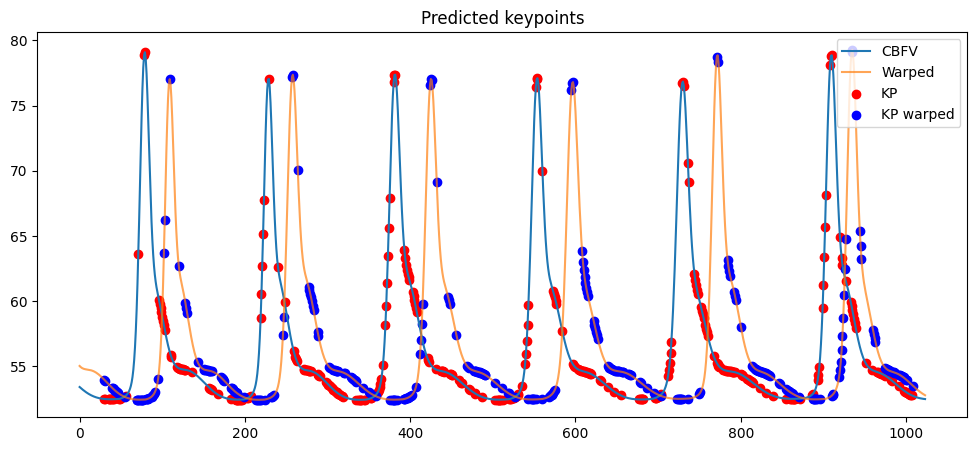

In [30]:
sample = dataset[0]
visualize(sample, model)

### Training Loss Evolution

Let's visualize the training loss over the epochs to observe the model's learning progress.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert loss_history to a DataFrame for easier plotting
loss_df = pd.DataFrame(loss_history)

plt.figure(figsize=(12, 6))
plt.plot(loss_df.index, loss_df['total'], label='Total Loss')
plt.plot(loss_df.index, loss_df['kp_orig'], label='Keypoint Original Loss')
plt.plot(loss_df.index, loss_df['kp_warped'], label='Keypoint Warped Loss')
plt.plot(loss_df.index, loss_df['desc'], label='Descriptor Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch')
plt.legend()
plt.grid(True)
plt.show()

### Other interesting plots to consider:

1.  **Distribution of Keypoint Scores (S_logits) after training:** This can show if the model is producing sharp keypoint predictions or if they are more spread out.
2.  **Descriptor Similarity Matrix:** Visualize the similarity between descriptors for original and warped keypoints to see how well the descriptor loss is working.
3.  **Heatmap of `match_mask` vs. predicted similarities:** This could help to qualitatively assess the descriptor matching.
4.  **Keypoint count per signal:** To see how many keypoints are being detected in average per signal, and if there are variations due to signal type or warping.
5.  **Histograms of keypoint positions:** To understand if keypoints are biased towards certain regions of the signal.

# Fine-tuning on real data

In [ ]:
model = TimePointModel().to(device)

checkpoint = torch.load("../checkpoints/model_epoch_29.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

Encoder freezing

In [ ]:
for param in model.encoder.parameters():
    param.requires_grad = False

In [ ]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

In [ ]:
dataset = NPZLoader(
    "../../data_for_finetuning/baseline",
    use_signal=SIGNAL_TO_TRAIN,
    window=1024
)

In [ ]:
epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in loader:
        x = batch["x"].to(device).unsqueeze(1)     # [B,1,L]
        x_w = batch["x_w"].to(device).unsqueeze(1)

        kp = batch["kp"].to(device)
        kp_w = batch["kp_w"].to(device)

        match_mask = batch["match_mask"].to(device)

        # forward
        S_logits, D = model(x)
        S_w_logits, D_w = model(x_w)

        # loss
        loss, loss_dict = criterion(
            S_logits, kp,
            S_w_logits, kp_w,
            D, D_w,
            match_mask
        )

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"\nEpoch {epoch}")
    print(f"Total loss: {total_loss:.4f}")
    print(loss_dict)

    # saving model weights
    save_path = os.path.join(save_dir, f"model_epoch_{epoch}.pth")
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": total_loss,
    }, save_path)

In [ ]:
sample = dataset[0]
visualize(sample, model)

In [ ]:
pth = np.load("/Users/weronikadomczewska/Documents/magisterskie/semestr3/magisterka/data_for_finetuning/baseline/sample_1.npz")

print(pth.files)